## Step 1: Import Required Libraries

In [26]:
# Import libraries for data analysis

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import libraries for data preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler

# Import evaluation metrics
from sklearn.metrics import accuracy_score, precision_score
from sklearn.metrics import recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix

# Import classification models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

# Import SMOTE for balancing the dataset
from imblearn.over_sampling import SMOTE

print("All Libraries Imported Successfully")

All Libraries Imported Successfully


## Step 2: Load the Dataset

In [27]:
# Load the Heart Failure dataset

df = pd.read_csv("heart_failure_clinical_records_dataset.csv")

# Display the first 5 rows
df.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


## Step 3: Dataset Analysis

In [28]:
# Check the number of rows and columns

print("Dataset Shape:", df.shape)

# Display column names

print("\nColumn Names:")
print(df.columns.tolist())

# Display dataset information

print("\nDataset Information:")
df.info()

Dataset Shape: (299, 13)

Column Names:
['age', 'anaemia', 'creatinine_phosphokinase', 'diabetes', 'ejection_fraction', 'high_blood_pressure', 'platelets', 'serum_creatinine', 'serum_sodium', 'sex', 'smoking', 'time', 'DEATH_EVENT']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       299 non-null    float64
 1   anaemia                   299 non-null    int64  
 2   creatinine_phosphokinase  299 non-null    int64  
 3   diabetes                  299 non-null    int64  
 4   ejection_fraction         299 non-null    int64  
 5   high_blood_pressure       299 non-null    int64  
 6   platelets                 299 non-null    float64
 7   serum_creatinine          299 non-null    float64
 8   serum_sodium              299 non-null    int64  
 9   sex                       299 

In [29]:
# Display statistical summary

df.describe()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
count,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.00000,299.000000,299.000000,299.00000,299.000000,299.00000
mean,60.833893,0.431438,581.839465,0.418060,38.083612,0.351171,263358.029264,1.39388,136.625418,0.648829,0.32107,130.260870,0.32107
std,11.894809,0.496107,970.287881,0.494067,11.834841,0.478136,97804.236869,1.03451,4.412477,0.478136,0.46767,77.614208,0.46767
min,40.000000,0.000000,23.000000,0.000000,14.000000,0.000000,25100.000000,0.50000,113.000000,0.000000,0.00000,4.000000,0.00000
25%,51.000000,0.000000,116.500000,0.000000,30.000000,0.000000,212500.000000,0.90000,134.000000,0.000000,0.00000,73.000000,0.00000
50%,60.000000,0.000000,250.000000,0.000000,38.000000,0.000000,262000.000000,1.10000,137.000000,1.000000,0.00000,115.000000,0.00000
75%,70.000000,1.000000,582.000000,1.000000,45.000000,1.000000,303500.000000,1.40000,140.000000,1.000000,1.00000,203.000000,1.00000
max,95.000000,1.000000,7861.000000,1.000000,80.000000,1.000000,850000.000000,9.40000,148.000000,1.000000,1.00000,285.000000,1.00000


## Step 4: Check Missing Values

In [30]:
# Check missing values in every column

missing_values = df.isnull().sum()

print(missing_values)

print("\nTotal Missing Values:", missing_values.sum())

age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64

Total Missing Values: 0


## Step 5: Check Duplicate Values

In [31]:
# Check duplicate rows

duplicates = df.duplicated().sum()

print("Total Duplicate Rows:", duplicates)

Total Duplicate Rows: 0


## Step 6: Check Whether Encoding is Required

In [32]:
# Check data types of all columns

print(df.dtypes)

age                         float64
anaemia                       int64
creatinine_phosphokinase      int64
diabetes                      int64
ejection_fraction             int64
high_blood_pressure           int64
platelets                   float64
serum_creatinine            float64
serum_sodium                  int64
sex                           int64
smoking                       int64
time                          int64
DEATH_EVENT                   int64
dtype: object


## Step 7: Analyze the Target Variable

In [33]:
# Count values in the target variable

print(df["DEATH_EVENT"].value_counts())

DEATH_EVENT
0    203
1     96
Name: count, dtype: int64


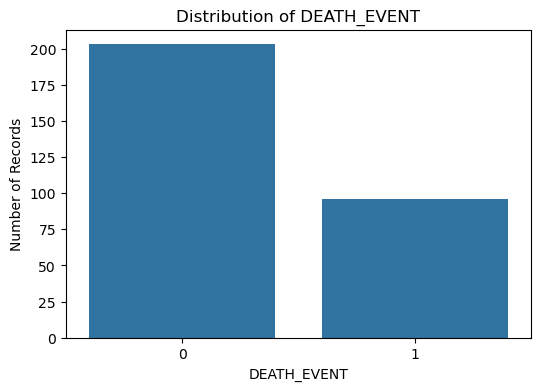

In [36]:
# Visualize target variable distribution

plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="DEATH_EVENT")

plt.title("Distribution of DEATH_EVENT")
plt.xlabel("DEATH_EVENT")
plt.ylabel("Number of Records")

plt.show()

## Step 8: Select Features and Target

In [10]:
# Separate input features and target variable

X = df.drop("DEATH_EVENT", axis=1)

y = df["DEATH_EVENT"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (299, 12)
Target Shape: (299,)


## Step 9: Split the Dataset into Training and Testing Data

In [11]:
# Split the dataset

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (239, 12)
Testing Data Shape: (60, 12)


## Step 10: Feature Scaling

In [12]:
# Create StandardScaler object

scaler = StandardScaler()

# Fit and transform training data

X_train_scaled = scaler.fit_transform(X_train)

# Transform testing data

X_test_scaled = scaler.transform(X_test)

print("Feature Scaling Completed Successfully")

Feature Scaling Completed Successfully


## Step 11: Check Dataset Balance

In [13]:
# Check class distribution before balancing

print("Class Distribution Before SMOTE:")

print(y_train.value_counts())

Class Distribution Before SMOTE:
DEATH_EVENT
0    162
1     77
Name: count, dtype: int64


## Step 12: Balance the Dataset using SMOTE

In [14]:
# Create SMOTE object

smote = SMOTE(random_state=42)

# Balance only the training dataset

X_train_balanced, y_train_balanced = smote.fit_resample(
    X_train_scaled,
    y_train
)

print("Class Distribution After SMOTE:")

print(pd.Series(y_train_balanced).value_counts())

Class Distribution After SMOTE:
DEATH_EVENT
0    162
1    162
Name: count, dtype: int64


## Step 13: Apply Different Classification Models

In [15]:
# Create different classification models

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": SVC(),
    "Naive Bayes": GaussianNB()
}

print("Total Models:", len(models))

Total Models: 6


## Step 14: Train and Compare All Classification Models

In [16]:
# Create an empty list to save model results

results = []

# Train each model one by one

for name, model in models.items():

    # Train the model using balanced training data
    model.fit(X_train_balanced, y_train_balanced)

    # Make predictions on testing data
    y_pred = model.predict(X_test_scaled)

    # Calculate evaluation metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    # Save results
    results.append([
        name,
        accuracy,
        precision,
        recall,
        f1
    ])

# Create a DataFrame for model comparison

results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score"
    ]
)

# Sort models by Accuracy

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True)

results_df

,Model,Accuracy,Precision,Recall,F1-Score
0,Random Forest,0.816667,0.722222,0.684211,0.702703
1,Logistic Regression,0.800000,0.733333,0.578947,0.647059
2,Decision Tree,0.783333,0.625000,0.789474,0.697674
3,KNN,0.750000,0.611111,0.578947,0.594595
4,Naive Bayes,0.750000,0.625000,0.526316,0.571429
5,SVM,0.733333,0.588235,0.526316,0.555556


## Step 15: Visual Comparison of Model Accuracy

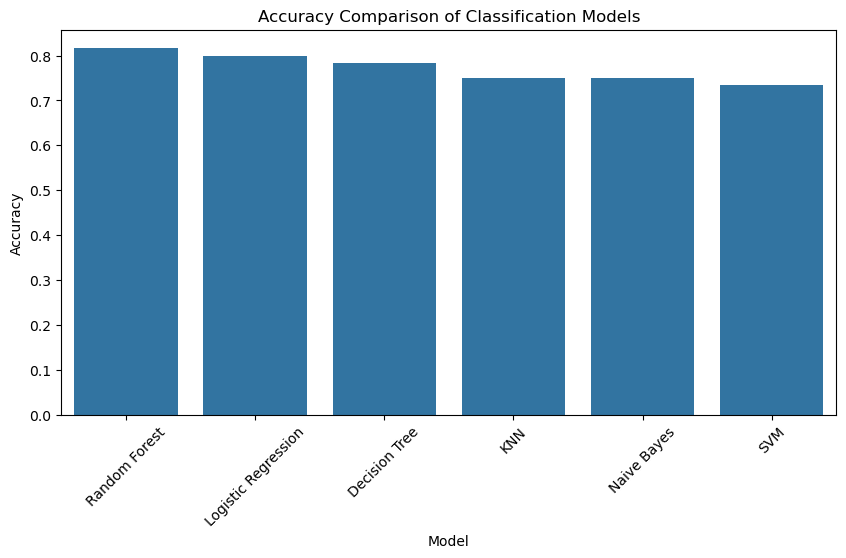

In [17]:
# Create accuracy comparison graph

plt.figure(figsize=(10, 5))

sns.barplot(
    data=results_df,
    x="Model",
    y="Accuracy"
)

plt.title("Accuracy Comparison of Classification Models")
plt.xticks(rotation=45)

plt.show()

## Step 16: Classification Report and Confusion Matrix

In [37]:
# Generate Classification Report and Confusion Matrix

for name, model in models.items():

    # Predict the test data
    y_pred = model.predict(X_test_scaled)

    print("\nModel:", name)

    # Classification Report
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    # Confusion Matrix
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))


Model: Logistic Regression

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.90      0.86        41
           1       0.73      0.58      0.65        19

    accuracy                           0.80        60
   macro avg       0.78      0.74      0.75        60
weighted avg       0.79      0.80      0.79        60

Confusion Matrix:
[[37  4]
 [ 8 11]]

Model: KNN

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.83      0.82        41
           1       0.61      0.58      0.59        19

    accuracy                           0.75        60
   macro avg       0.71      0.70      0.71        60
weighted avg       0.75      0.75      0.75        60

Confusion Matrix:
[[34  7]
 [ 8 11]]

Model: Decision Tree

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.78      0.83        41
           1       0.62      

### Explanation
The Classification Report provides:
- Precision
- Recall
- F1-Score
- Support

The Confusion Matrix shows how many predictions were correct and incorrect.

## Step 17: Select the Best Performing Model

In [38]:
# Select the model with the highest Accuracy

best_model_name = results_df.iloc[0]["Model"]

best_accuracy = results_df.iloc[0]["Accuracy"]

print("Best Performing Model:", best_model_name)

print("Best Model Accuracy:", round(best_accuracy, 4))

Best Performing Model: Random Forest
Best Model Accuracy: 0.8167


## Step 18: Hyperparameter Tuning of the Best Model

In [39]:
# We will tune the model selected as the best model.
# Different models require different parameters.

if best_model_name == "Random Forest":

    model_for_tuning = RandomForestClassifier(random_state=42)

    param_grid = {
        "n_estimators": [50, 100, 200],
        "max_depth": [None, 5, 10],
        "min_samples_split": [2, 5]
    }

elif best_model_name == "Decision Tree":

    model_for_tuning = DecisionTreeClassifier(random_state=42)

    param_grid = {
        "max_depth": [None, 3, 5, 10],
        "min_samples_split": [2, 5, 10],
        "criterion": ["gini", "entropy"]
    }

elif best_model_name == "KNN":

    model_for_tuning = KNeighborsClassifier()

    param_grid = {
        "n_neighbors": [3, 5, 7, 9],
        "weights": ["uniform", "distance"]
    }

elif best_model_name == "SVM":

    model_for_tuning = SVC()

    param_grid = {
        "C": [0.1, 1, 10],
        "kernel": ["linear", "rbf"]
    }

elif best_model_name == "Logistic Regression":

    model_for_tuning = LogisticRegression(max_iter=1000)

    param_grid = {
        "C": [0.01, 0.1, 1, 10]
    }

else:

    # Parameters for Naive Bayes
    model_for_tuning = GaussianNB()

    param_grid = {
        "var_smoothing": np.logspace(-11, -7, 5)
    }

# Apply GridSearchCV

grid_search = GridSearchCV(
    estimator=model_for_tuning,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy"
)

# Train GridSearchCV using balanced training data

grid_search.fit(
    X_train_balanced,
    y_train_balanced
)

print("Best Parameters:")

print(grid_search.best_params_)

print("\nBest Cross Validation Accuracy:")

print(round(grid_search.best_score_, 4))

Best Parameters:
{'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}

Best Cross Validation Accuracy:
0.8889


## Step 19: Evaluate the Tuned Model

In [40]:
# Get the optimized model

tuned_model = grid_search.best_estimator_

# Make predictions

y_pred_tuned = tuned_model.predict(X_test_scaled)

# Calculate final evaluation metrics

tuned_accuracy = accuracy_score(y_test, y_pred_tuned)

tuned_precision = precision_score(
    y_test,
    y_pred_tuned,
    zero_division=0
)

tuned_recall = recall_score(
    y_test,
    y_pred_tuned,
    zero_division=0
)

tuned_f1 = f1_score(
    y_test,
    y_pred_tuned,
    zero_division=0
)

print("FINAL TUNED MODEL RESULTS")
print("=" * 50)

print("Model:", best_model_name)

print("Accuracy:", round(tuned_accuracy, 4))

print("Precision:", round(tuned_precision, 4))

print("Recall:", round(tuned_recall, 4))

print("F1-Score:", round(tuned_f1, 4))

FINAL TUNED MODEL RESULTS
Model: Random Forest
Accuracy: 0.8167
Precision: 0.7222
Recall: 0.6842
F1-Score: 0.7027


## Step 20: Classification Report of Final Tuned Model

In [41]:
# Display Classification Report

print(classification_report(
    y_test,
    y_pred_tuned,
    zero_division=0
))

              precision    recall  f1-score   support

           0       0.86      0.88      0.87        41
           1       0.72      0.68      0.70        19

    accuracy                           0.82        60
   macro avg       0.79      0.78      0.79        60
weighted avg       0.81      0.82      0.82        60



## Step 21: Final Confusion Matrix

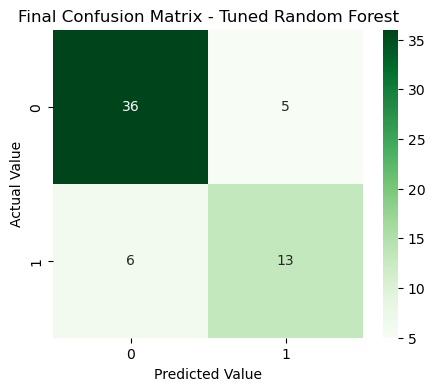

In [52]:
cm = confusion_matrix(
    y_test,
    y_pred_tuned
)

plt.figure(figsize=(5, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title(
    "Final Confusion Matrix - Tuned " + best_model_name
)

plt.xlabel("Predicted Value")
plt.ylabel("Actual Value")

plt.show()

In [50]:
# OR

In [53]:
# Create Confusion Matrix for the final optimized model

cm = confusion_matrix(y_test, y_pred_tuned)

print("Final Confusion Matrix:")
print(cm)

Final Confusion Matrix:
[[36  5]
 [ 6 13]]


## Step 22: Compare Before and After Hyperparameter Tuning

In [43]:
# Get the original best model result

original_best_accuracy = results_df.iloc[0]["Accuracy"]

# Create comparison table

tuning_comparison = pd.DataFrame({
    "Model Version": [
        "Before Hyperparameter Tuning",
        "After Hyperparameter Tuning"
    ],

    "Accuracy": [
        original_best_accuracy,
        tuned_accuracy
    ]
})

tuning_comparison

,Model Version,Accuracy
0,Before Hyperparameter Tuning,0.816667
1,After Hyperparameter Tuning,0.816667


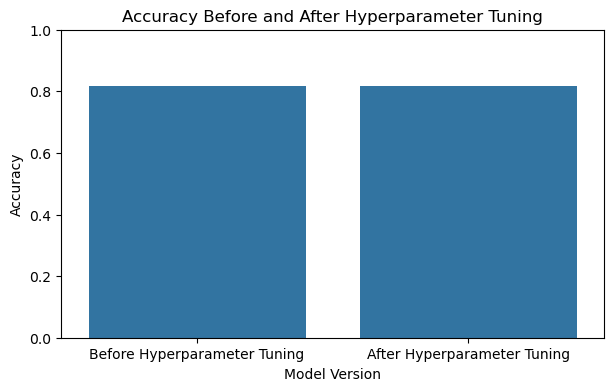

In [44]:
# Visual comparison of accuracy before and after tuning

plt.figure(figsize=(7, 4))

sns.barplot(
    data=tuning_comparison,
    x="Model Version",
    y="Accuracy"
)

plt.title("Accuracy Before and After Hyperparameter Tuning")

plt.ylim(0, 1)

plt.show()